# Step 15 — Frozen external-evaluation contract

## tl;dr

This artifact-only notebook freezes the complete 20-case 3D-IRCADb-01 cohort, preprocessing, three model/checkpoint identities, ROI construction, fusion, threshold, metrics, train-derived strata, acceptance gates, one-time execution rule, and failure policy **before external inference**.

It performs no model loading or inference and opens no local LiTS test image, mask, loader, probability cache, or test statistic. A successful run produces `EXTERNAL_EVALUATION_CONTRACT_FROZEN_AWAITING_AUTHORIZATION`, not an external-performance result.


## Context & Methods

### Key assumptions

- The signed Step 14 normalized files are the complete external cohort; no case is excluded.
- External DICOM geometry is standardized to the original 256×256 broad-window representation before applying the frozen model policy.
- Performance thresholds come from the validation-era freeze, not from external outcomes.
- Step 16 may execute exactly once only after explicit authorization. Results may not trigger tuning, threshold sweeps, checkpoint selection, post-processing, or reruns except a documented technical failure before a complete result is produced.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, platform, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STEP_DIR=Path.cwd().resolve(); assert STEP_DIR.name=="step_15_frozen_external_evaluation_contract"
PART2=STEP_DIR.parent; PROJECT_ROOT=PART2.parent
OUT=STEP_DIR/"outputs"; OUT.mkdir(exist_ok=True)
S1=PART2/"step_01_pretraining_dataset_characterization"/"outputs"
S2=PART2/"step_02_fusion_freeze_confirmation"/"outputs"
S3=PART2/"step_03_final_inference_policy_freeze"/"outputs"
STEP14_DIR=PART2/"step_14_3d_ircadb_normalized_conversion_and_parity_qc"; S14=STEP14_DIR/"outputs"
EXPECTED_MANIFEST="575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
EXPECTED_STEP14_ARCHIVE_SET="55cd6722da6c02f8365ab566603db116128e0d854782d2a174b85056f4a5ba96"
EXPECTED_HASHES={"control":"9b0c7749af66b0fc3808f6757d0d90af01384e06afe02090361b220df48b6e8b",
 "recall_loss":"c01eb4b81e4e7f1d84c7966aca56e738d87d06d404907f0bcc7c67a79ed4ec4d",
 "roi_generator":"9c4160bbd68891f9dc4e5f04ceca4391f38c5869b3f81c72b95d4639e0572223"}
CHECKPOINTS={"control":PROJECT_ROOT/"mark 1"/"mark_4_outputs"/"mark_4_best.pth",
 "recall_loss":PROJECT_ROOT/"mark 1"/"mark_4c_outputs"/"recall_loss_best.pth",
 "roi_generator":PROJECT_ROOT/"Practice"/"multitask_liver_tumor_outputs"/"multitask_best.pth"}
MODEL_SOURCE=PROJECT_ROOT/"src"/"framework"/"models"/"mobilenetv2_unet.py"
AUTHORIZATION_GRANTED=False
EXPECTED_AUTHORIZATION_TEXT="I authorize the one-time Step 16 3D-IRCADb-01 external evaluation under the frozen Step 15 contract."

def sha256(p,chunk=1024*1024):
 h=hashlib.sha256()
 with Path(p).open("rb") as f:
  for b in iter(lambda:f.read(chunk),b""): h.update(b)
 return h.hexdigest()
def loadj(p): return json.loads(Path(p).read_text(encoding="utf-8"))
def savej(obj,name): (OUT/name).write_text(json.dumps(obj,indent=2,sort_keys=True,default=str),encoding="utf-8")
def savec(df,name): df.to_csv(OUT/name,index=False)
print("Artifact-only contract freeze; inference=False; local LiTS test access=False")

Artifact-only contract freeze; inference=False; local LiTS test access=False


## Data

### 1. Verify signed prerequisites and immutable identities


In [2]:
g1=loadj(S1/"gate_result.json"); bins=loadj(S1/"sampling_policy.json")["bin_edges"]
g2=loadj(S2/"gate_result.json"); p2=loadj(S2/"immutable_inference_policy.json")
g3=loadj(S3/"gate_result.json"); p3=loadj(S3/"final_inference_policy.json"); sig3=loadj(S3/"freeze_signature.json")
g14=loadj(S14/"gate_result.json"); sig14=loadj(S14/"step_14_signature.json")

sig14_rows=[]
for rel,exp in sig14["signed_artifacts"].items():
 p=PART2/rel; act=sha256(p) if p.is_file() else None
 sig14_rows.append({"artifact":rel,"exists":p.is_file(),"expected_sha256":exp,"actual_sha256":act,"passed":act==exp})
sig14_check=pd.DataFrame(sig14_rows); savec(sig14_check,"step_14_signature_verification.csv")

checkpoint_rows=[]
for name,p in CHECKPOINTS.items():
 act=sha256(p) if p.is_file() else None
 checkpoint_rows.append({"role":name,"path":str(p),"exists":p.is_file(),"bytes":p.stat().st_size if p.is_file() else None,
                         "expected_sha256":EXPECTED_HASHES[name],"actual_sha256":act,"passed":act==EXPECTED_HASHES[name]})
checkpoint_integrity=pd.DataFrame(checkpoint_rows); savec(checkpoint_integrity,"checkpoint_integrity.csv")

checks=pd.DataFrame([
 {"check":"step01_train_derived_bins_ready","passed":g1.get("all_mandatory_targets_passed") is True},
 {"check":"step02_validation_freeze_pass","passed":g2.get("result_level")=="VALIDATION_FREEZE_PASS"},
 {"check":"step03_policy_freeze_pass","passed":g3.get("result_level")=="VALIDATION_FREEZE_PASS"},
 {"check":"step03_policy_hash_matches_signature","passed":sha256(S3/"final_inference_policy.json")==sig3["final_inference_policy_sha256"]},
 {"check":"step14_conversion_gate_pass","passed":g14.get("conversion_qc_passed") is True},
 {"check":"step14_archive_identity","passed":g14.get("archive_set_sha256")==EXPECTED_STEP14_ARCHIVE_SET},
 {"check":"step14_signed_artifacts_match","passed":bool(sig14_check.passed.all())},
 {"check":"all_three_checkpoint_hashes_match","passed":bool(checkpoint_integrity.passed.all())},
 {"check":"manifest_identity_preserved","passed":g14.get("manifest_sha256")==EXPECTED_MANIFEST},
 {"check":"model_source_present","passed":MODEL_SOURCE.is_file()},
 {"check":"external_inference_not_authorized","passed":AUTHORIZATION_GRANTED is False},
 {"check":"local_lits_test_access_disabled","passed":True},
])
savec(checks,"input_verification.csv"); assert checks.passed.all(),checks.loc[~checks.passed].to_dict("records")
print("PASS: all signed prerequisites and checkpoint identities match")

PASS: all signed prerequisites and checkpoint identities match


### 2. Freeze the complete cohort and train-derived difficulty strata

Physical tumour burden uses Step 14 source voxels and physical voxel volume. Stratum edges come exclusively from Step 01 training data. A source tumour folder is treated as a lesion proxy and is reported as such.


In [3]:
conv=pd.read_csv(S14/"conversion_manifest.csv"); geo=pd.read_csv(S14/"patient_geometry_profile.csv")
lab=pd.read_csv(S14/"label_pixel_profile.csv"); cont=pd.read_csv(S14/"tumour_folder_vs_nonzero_audit.csv"); hu=pd.read_csv(S14/"hu_profile.csv")
cohort=conv.merge(geo,on=["source_patient_id","internal_patient_id"],validate="one_to_one").merge(cont,on=["source_patient_id","internal_patient_id"],validate="one_to_one").merge(hu,on=["source_patient_id","internal_patient_id"],validate="one_to_one")
assert len(cohort)==20 and cohort.internal_patient_id.is_unique and int(cohort.tumour_union_nonzero.sum())==15
cohort["voxel_volume_ml"]=cohort.spacing_x_mm*cohort.spacing_y_mm*cohort.spacing_z_mm/1000
cohort["liver_volume_ml_external"]=cohort.liver_voxels*cohort.voxel_volume_ml
cohort["tumour_volume_ml_external"]=cohort.tumour_voxels*cohort.voxel_volume_ml
burden_edges=bins["patient_tumour_volume_ml"]
cohort["train_derived_burden_stratum"]=pd.cut(cohort.tumour_volume_ml_external,
 bins=burden_edges,labels=["burden_q1","burden_q2","burden_q3","burden_q4"],include_lowest=True).astype(str)
cohort.loc[~cohort.tumour_union_nonzero,"train_derived_burden_stratum"]="tumour_negative"
cohort["evaluation_included"]=True; cohort["primary_positive_population"]=cohort.tumour_union_nonzero.astype(bool)
cohort["negative_control_population"]=(~cohort.tumour_union_nonzero.astype(bool))
path_cols=["ct_relative_path","liver_relative_path","tumour_relative_path"]
for col in path_cols: cohort[col+"_exists"]=cohort[col].map(lambda x:(STEP14_DIR/x).is_file())
assert cohort[[x+"_exists" for x in path_cols]].all().all()
savec(cohort,"external_cohort_registry.csv")

lesions=lab.merge(geo[["internal_patient_id","spacing_x_mm","spacing_y_mm","spacing_z_mm"]],on="internal_patient_id",validate="many_to_one")
lesions["lesion_proxy_volume_ml"]=lesions.nonzero_voxels*lesions.spacing_x_mm*lesions.spacing_y_mm*lesions.spacing_z_mm/1000
lesion_edges=bins["lesion_volume_ml"]
lesions["train_derived_lesion_stratum"]=pd.cut(lesions.lesion_proxy_volume_ml,bins=lesion_edges,
 labels=["lesion_q1","lesion_q2","lesion_q3","lesion_q4"],include_lowest=True).astype(str)
lesions["definition_caveat"]="one source livertumor folder used as lesion proxy"
savec(lesions,"external_lesion_strata.csv")

cohort_summary=pd.DataFrame([
 {"metric":"all_cases","value":len(cohort)}, {"metric":"tumour_positive_cases","value":int(cohort.tumour_union_nonzero.sum())},
 {"metric":"tumour_negative_cases","value":int((~cohort.tumour_union_nonzero).sum())}, {"metric":"lesion_proxy_folders","value":len(lesions)},
 *[{"metric":f"patients_{k}","value":int(v)} for k,v in cohort.train_derived_burden_stratum.value_counts().sort_index().items()],
 *[{"metric":f"lesions_{k}","value":int(v)} for k,v in lesions.train_derived_lesion_stratum.value_counts().sort_index().items()],
])
savec(cohort_summary,"external_cohort_summary.csv"); display(cohort_summary)

,metric,value
0,all_cases,20
1,tumour_positive_cases,15
2,tumour_negative_cases,5
3,lesion_proxy_folders,24
4,patients_burden_q1,1
5,patients_burden_q2,7
6,patients_burden_q4,7
7,patients_tumour_negative,5
8,lesions_lesion_q2,2
9,lesions_lesion_q3,4


### 3. Quantify external geometry shift against training only

This comparison is descriptive and cannot change the model policy. No validation or test patient is used to fit limits.


In [4]:
train_geo=pd.read_csv(S1/"volume_geometry_profile.csv").query("split == 'train'").copy()
comparisons=[("spacing_x_mm","spacing_x_mm"),("spacing_z_mm","slice_thickness_mm"),("slices_z","slices_z"),("liver_volume_ml_external","liver_volume_ml")]
shift=[]
for ext_col,tr_col in comparisons:
 tr=pd.to_numeric(train_geo[tr_col],errors="coerce").dropna(); ex=pd.to_numeric(cohort[ext_col],errors="coerce").dropna()
 q1,q3=tr.quantile([.25,.75]); lo=q1-1.5*(q3-q1); hi=q3+1.5*(q3-q1)
 shift.append({"feature":ext_col,"train_n":len(tr),"external_n":len(ex),"train_min":tr.min(),"train_median":tr.median(),"train_max":tr.max(),
  "external_min":ex.min(),"external_median":ex.median(),"external_max":ex.max(),"external_outside_train_range_n":int(((ex<tr.min())|(ex>tr.max())).sum()),
  "external_train_iqr_outlier_n":int(((ex<lo)|(ex>hi)).sum()),"train_iqr_lower":lo,"train_iqr_upper":hi})
domain_shift=pd.DataFrame(shift); savec(domain_shift,"external_train_geometry_shift.csv"); display(domain_shift)

,feature,train_n,external_n,train_min,train_median,train_max,external_min,external_median,external_max,external_outside_train_range_n,external_train_iqr_outlier_n,train_iqr_lower,train_iqr_upper
0,spacing_x_mm,104,20,0.556641,0.772461,1.000,0.561000,0.739094,0.873047,0,0,0.392578,1.220703
1,spacing_z_mm,104,20,0.699984,1.000000,5.000,1.000000,1.600000,4.000000,0,1,-1.000000,3.800000
2,slices_z,104,20,74.000000,263.000000,917.000,74.000000,127.000000,260.000000,0,0,-581.375000,1355.625000
3,liver_volume_ml_external,104,20,583.208000,1635.955753,3341.433,1153.316602,1578.075507,2118.117557,0,0,622.752195,2665.929575


## Results

### 4. Freeze preprocessing, metrics, gates, and execution rules


In [5]:
policy={
 "schema_version":"1.0","status":"FROZEN_AWAITING_EXPLICIT_ONE_TIME_AUTHORIZATION","frozen_utc":datetime.now(timezone.utc).isoformat(),
 "source":{"dataset":"3D-IRCADb-01","license":"CC BY-NC-ND 4.0","redistribution_authorized":False,
  "step14_signature_sha256":sha256(S14/"step_14_signature.json"),"step14_combined_sha256":sig14["combined_sha256"],
  "archive_set_sha256":EXPECTED_STEP14_ARCHIVE_SET,"cohort_registry":"external_cohort_registry.csv",
  "all_cases_included":True,"patients":20,"tumour_positive_patients":15,"tumour_negative_patients":5},
 "model":{"architecture":"MobileNetV2UNet","source_path":str(MODEL_SOURCE),"source_sha256":sha256(MODEL_SOURCE),
  "control_checkpoint":str(CHECKPOINTS["control"]),"control_sha256":EXPECTED_HASHES["control"],
  "recall_checkpoint":str(CHECKPOINTS["recall_loss"]),"recall_sha256":EXPECTED_HASHES["recall_loss"],
  "roi_checkpoint":str(CHECKPOINTS["roi_generator"]),"roi_sha256":EXPECTED_HASHES["roi_generator"],"strict_state_loading":True},
 "preprocessing":{"normalized_input":"Step 14 NIfTI ct_hu/liver_mask/tumour_mask","slice_array_rule":"volume[:,:,z]",
  "full_grid":[256,256],"hu_clip":[-160,240],"uint8_rule":"rint((clip(HU,-160,240)+160)/400*255)",
  "full_slice_image_resize":"PIL bilinear to 256x256","full_slice_mask_resize":"PIL nearest to 256x256","external_orientation_transform":"none",
  "roi_generator_input":"broad uint8/255 then per-slice positive-pixel median and IQR/1.349 robust z; fallback whole slice; clip [-3,3], map [0,1]",
  "roi_liver_score":"sigmoid(logit)[:,0]","roi_liver_threshold":0.5,"roi_component":"largest 3D, connectivity 26",
  "roi_padding_pixels_on_256_grid":16,"empty_roi_fallback":"full_image_box_[0,256,0,256]",
  "tumour_crop_resize":"bilinear image to 256x256","truth_crop_resize":"nearest mask to 256x256",
  "inverse_mapping":"bilinear probability resize into frozen full-grid ROI box"},
 "prediction":{"score":"sigmoid(logit)","fusion":"maximum(control_probability, recall_probability)","global_threshold":0.70,
  "hard_rule":"fused_probability >= 0.70","post_processing":"none","inference_dtype":"float32","probability_cache_dtype":"float16"},
 "metrics":{"epsilon":1e-6,"primary":"mean patient Dice over all 15 tumour-positive patients",
  "dice":"(2*intersection+epsilon)/(truth_pixels+predicted_pixels+epsilon)","empty_truth":"reported separately and excluded from positive-patient mean",
  "bootstrap":{"iterations":10000,"seed":42,"unit":"tumour-positive patient"},
  "q1_positive_slice":"1 to 51 truth pixels inclusive on standardized full 256x256 grid; threshold derived from LiTS train only",
  "subgroups":{"patient_burden_edges_ml":bins["patient_tumour_volume_ml"],"lesion_proxy_edges_ml":bins["lesion_volume_ml"],
    "geometry":"slice spacing and in-plane spacing","contrast":"tumour_minus_liver_hu"}},
 "execution":{"mode":"one_time_external_evaluation","batch_size":24,"num_workers":0,"random_seed":42,
  "authorization_required":True,"expected_authorization_text":EXPECTED_AUTHORIZATION_TEXT,
  "no_result_driven_changes":["threshold tuning","threshold sweeps","checkpoint selection","fusion changes","post-processing changes","case exclusion","retraining"],
  "technical_failure_rule":"rerun only if ledger proves no complete metric result was produced; record repair and reuse preserved probability files only after integrity verification"},
 "safety":{"model_inference_performed_in_step15":False,"local_lits_test_access_allowed":False,"local_lits_test_accessed":False}
}
savej(policy,"frozen_external_evaluation_policy.json")

acceptance=pd.DataFrame([
 ["integrity","sample_coverage_fraction",">=",1.0,True],["integrity","unique_patient_id_fraction",">=",1.0,True],
 ["integrity","finite_probability_fraction",">=",1.0,True],["integrity","checkpoint_hashes_match",">=",1.0,True],
 ["performance","mean_positive_patient_dice",">=",0.3329,True],["performance","minimum_positive_patient_dice",">=",0.01,True],
 ["performance","q1_positive_slice_detection_pct",">=",35.0,True],["performance","positive_predicted_empty_pct","<=",35.0,True],
 ["performance","empty_slice_false_positive_pct","<=",20.0,True],
 ["reporting","all_20_patient_rows_saved",">=",1.0,True],["reporting","burden_and_negative_subgroups_saved",">=",1.0,True],
],columns=["category","metric","operator","threshold","mandatory"])
acceptance["derivation"]=["Step15 integrity","Step15 integrity","Step15 integrity","Step15 integrity","frozen validation floor","robustness floor",
 "frozen validation floor using train-only edge","frozen validation ceiling","frozen validation ceiling","Step15 reporting","Step15 reporting"]
savec(acceptance,"external_acceptance_contract.csv")
savej({"schema_version":"1.0","declared_before_external_inference":True,"table":"external_acceptance_contract.csv",
 "failure_action":"Report the completed external result without tuning or rerun; preserve negative findings.",
 "formal_model_acceptance_note":"Existing project acceptance remains failed; external evaluation is an independent generalization analysis and cannot retroactively change the one-time LiTS result."},"external_acceptance_contract.json")

### 5. Evaluate freeze readiness and sign the contract


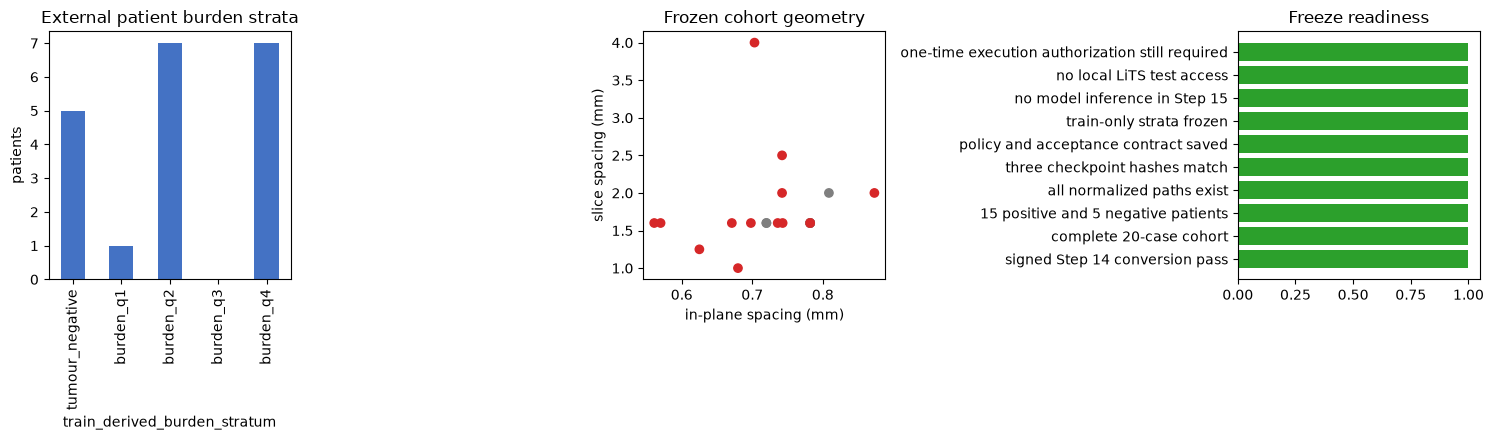

{
  "created_utc": "2026-08-05T14:29:30.960810+00:00",
  "result_level": "EXTERNAL_EVALUATION_CONTRACT_FROZEN_AWAITING_AUTHORIZATION",
  "contract_frozen": true,
  "ready_for_explicit_authorization": true,
  "authorization_granted": false,
  "expected_authorization_text": "I authorize the one-time Step 16 3D-IRCADb-01 external evaluation under the frozen Step 15 contract.",
  "next_step": "step_16_one_time_external_evaluation_after_explicit_authorization",
  "cohort": {
    "all": 20,
    "tumour_positive": 15,
    "tumour_negative": 5,
    "excluded": 0
  },
  "inference_performed": false,
  "formal_external_evaluation_performed": false,
  "local_lits_test_accessed": false,
  "manifest_sha256": "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
}


In [6]:
requirements=pd.DataFrame([
 {"requirement":"signed Step 14 conversion pass","passed":g14["conversion_qc_passed"] is True},
 {"requirement":"complete 20-case cohort","passed":len(cohort)==20 and cohort.evaluation_included.all()},
 {"requirement":"15 positive and 5 negative patients","passed":int(cohort.primary_positive_population.sum())==15 and int(cohort.negative_control_population.sum())==5},
 {"requirement":"all normalized paths exist","passed":bool(cohort[[x+"_exists" for x in path_cols]].all().all())},
 {"requirement":"three checkpoint hashes match","passed":bool(checkpoint_integrity.passed.all())},
 {"requirement":"policy and acceptance contract saved","passed":True},
 {"requirement":"train-only strata frozen","passed":bins["derivation_split"]=="train" and bins["validation_used_to_fit"] is False},
 {"requirement":"no model inference in Step 15","passed":True},
 {"requirement":"no local LiTS test access","passed":True},
 {"requirement":"one-time execution authorization still required","passed":AUTHORIZATION_GRANTED is False},
])
savec(requirements,"freeze_readiness.csv"); freeze_pass=bool(requirements.passed.all())
result="EXTERNAL_EVALUATION_CONTRACT_FROZEN_AWAITING_AUTHORIZATION" if freeze_pass else "EXTERNAL_EVALUATION_CONTRACT_FREEZE_FAIL"

fig,ax=plt.subplots(1,3,figsize=(15,4.5))
cohort.train_derived_burden_stratum.value_counts().reindex(["tumour_negative","burden_q1","burden_q2","burden_q3","burden_q4"],fill_value=0).plot.bar(ax=ax[0],color="#4472c4"); ax[0].set_title("External patient burden strata"); ax[0].set_ylabel("patients")
ax[1].scatter(cohort.spacing_x_mm,cohort.spacing_z_mm,c=cohort.tumour_union_nonzero.map({True:"#d62728",False:"#7f7f7f"})); ax[1].set_xlabel("in-plane spacing (mm)"); ax[1].set_ylabel("slice spacing (mm)"); ax[1].set_title("Frozen cohort geometry")
ax[2].barh(requirements.requirement,requirements.passed.astype(int),color=np.where(requirements.passed,"#2ca02c","#d62728")); ax[2].set_xlim(0,1.05); ax[2].set_title("Freeze readiness")
fig.tight_layout(); fig.savefig(OUT/"external_contract_dashboard.png",dpi=160,bbox_inches="tight"); plt.show()

gate={"created_utc":datetime.now(timezone.utc).isoformat(),"result_level":result,"contract_frozen":freeze_pass,
 "ready_for_explicit_authorization":freeze_pass,"authorization_granted":False,"expected_authorization_text":EXPECTED_AUTHORIZATION_TEXT,
 "next_step":"step_16_one_time_external_evaluation_after_explicit_authorization" if freeze_pass else "repair_step_15",
 "cohort":{"all":20,"tumour_positive":15,"tumour_negative":5,"excluded":0},"inference_performed":False,
 "formal_external_evaluation_performed":False,"local_lits_test_accessed":False,"manifest_sha256":EXPECTED_MANIFEST}
savej(gate,"gate_result.json")
savej({"phase":STEP_DIR.name,"created_utc":gate["created_utc"],"python":sys.version,"platform":platform.platform(),
 "step14_signature_sha256":sha256(S14/"step_14_signature.json"),"step03_policy_sha256":sha256(S3/"final_inference_policy.json"),
 "model_source_sha256":sha256(MODEL_SOURCE),"inference_performed":False,"local_lits_test_accessed":False},"provenance.json")

sign_names=["input_verification.csv","step_14_signature_verification.csv","checkpoint_integrity.csv","external_cohort_registry.csv",
 "external_cohort_summary.csv","external_lesion_strata.csv","external_train_geometry_shift.csv","frozen_external_evaluation_policy.json",
 "external_acceptance_contract.csv","external_acceptance_contract.json","freeze_readiness.csv","external_contract_dashboard.png","gate_result.json","provenance.json"]
signed={str((OUT/n).relative_to(PART2)):sha256(OUT/n) for n in sign_names}
combined=hashlib.sha256("\n".join(f"{k}:{v}" for k,v in sorted(signed.items())).encode()).hexdigest()
savej({"algorithm":"SHA-256","created_utc":datetime.now(timezone.utc).isoformat(),"combined_sha256":combined,
 "result_level":result,"signed_artifacts":signed,"inference_performed":False,"local_lits_test_accessed":False},"step_15_signature.json")
print(json.dumps(gate,indent=2)); assert freeze_pass

## Takeaways

- The complete external cohort and all policies are frozen before inference.
- Step 15 is a contract/readiness pass only; it contains no external model result.
- The next action is explicit authorization for the one-time Step 16 execution using the exact sentence recorded in `gate_result.json`.
- Whether Step 16 passes or fails, its complete result must be reported without data-driven changes or reruns.
